# Team 5 — IT5006 Phase 2: Analytics Implementation
## Problem definition, model building and evaluation — *Fair freight (regression) and late delivery (classification)*

Two problems, built on the Phase 1 candidate analysis, both about the logistics of an Olist order:

| | **Problem 1 — regression** | **Problem 2 — classification** |
|---|---|---|
| **Question** | What freight *should* this item be charged? | Will this order arrive after its promised date? |
| **Stakeholder** | Logistics-pricing / marketplace-finance analyst | Operations and customer-experience team |
| **Grain / target** | Order item · `log1p(freight_value)` | Delivered order · `is_late` = delivered on a calendar day after the promised date (Phase 1 definition, 6.8% positive) |
| **Validation** | 80/20 hold-out grouped by order; robustness by product and by time | **Time-ordered**: train on earlier orders, test on the latest 20%, 30-day embargo, forward-chaining CV |
| **Metrics** | MAE, RMSE, R² | Precision, Recall, F1, ROC-AUC, **PR-AUC and its lift over the late rate** |

**Model families (3), shared by both problems:** Linear (LinearRegression → Ridge; plain Logistic → L2 Logistic) · Tree-based (DecisionTree baseline → RandomForest) · Ensemble (Stacking for Problem 1; soft Voting for Problem 2, see Section 6).
Seed `RANDOM_STATE = 42` everywhere. All preprocessing sits inside scikit-learn `Pipeline`s.

**Reproduce:** put the nine Olist CSVs in `data/` (or set `OLIST_DATA_DIR`), `pip install -r requirements.txt`, run top to bottom (about 15 minutes on 12 cores).

In [1]:
import os, sys, warnings, platform
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from IPython.display import display
import features as F, models as M, pipeline as P, plots as PL

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None); pd.set_option("display.html.use_mathjax", False)   # "R$" is currency, not maths
print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seed {F.RANDOM_STATE}")

python 3.14.3 | pandas 2.3.3 | numpy 2.4.2 | scikit-learn 1.8.0 | seed 42


## 1. Problem statements and stakeholders

**Problem 1 — fair freight (regression).** Freight is about 14% of GMV and a median 23% of an item's price (Phase 1), yet roughly half of its variation is *not* explained by parcel weight, volume and distance. The **logistics-pricing / marketplace-finance analyst** who sets and audits freight needs an expected ("fair") freight for every item at checkout, to quote prices, review tariffs and spot items charged far above expectation.

**Problem 2 — late delivery (classification).** Delivery performance drives satisfaction: late orders average about 2.3 review stars against 4.3 for on-time ones (Phase 1). The **operations and customer-experience team** that sets delivery promises and intervenes on at-risk orders needs, at the moment of purchase, a **risk ranking** of orders likely to arrive after the promised date, so it can re-set the promise, expedite or contact the buyer.

**Success criteria (set before modelling).**
* Problem 1: a held-out MAE below 20% of mean freight (about R\$4), beating the mean predictor and the linear baseline; errors reported by price band.
* Problem 2: on orders placed *after* the training period, a PR-AUC clearly above the late rate (lift > 1.5); when the riskiest 10% of orders are flagged, catch at least twice the late orders that random review would (recall ≥ 20%).
* For both: a more complex model is kept only if it beats its simpler baseline by more than one fold standard deviation of CV score.

**Why these metrics (Phase 1 literature review).**
* **Problem 1.** MAE in R\$ is the primary metric: RMSE mixes the size of errors with their spread and is dominated by the long right tail of freight (Willmott & Matsuura, 2005); RMSE and R² are reported alongside. MAPE, the metric of the closest precedent (Budzyński & Cieśla, 2025), is not used, because percentage errors are undefined or unstable when the actual value is zero or near zero (Hyndman & Koehler, 2006) and 0.3% of items have zero freight. Errors are broken down by price band rather than pooled, because a near-flat freight weighs most on cheap items (Phase 1).
* **Problem 2.** With 6.8% of orders late, accuracy is uninformative: always predicting "on time" scores 93% (He & Garcia, 2009). The primary metric is **PR-AUC**, which is more informative than ROC-AUC when positives are rare (Saito & Rehmsmeier, 2015). A no-skill model's PR-AUC equals the late rate, which differs between periods, so we report its **lift** = PR-AUC / late rate (1 = no skill) to compare periods. ROC-AUC is reported as a secondary ranking measure, and precision, recall and F1 for the operating rule (flag the riskiest 10% of orders, Section 6).

### Problem-scoping checklist

| Checklist item | Problem 1 (freight) | Problem 2 (is_late) |
|---|---|---|
| 1. Target computable from provided tables, no external data | `freight_value` comes from `order_items`. | `is_late` = delivered date vs estimated date from `orders` (Phase 1 definition). |
| 2. All predictors exist before the outcome (no leakage) | Listing, address and basket fields fixed at checkout. | Checkout-time fields only, including the promised date; delivery, carrier, approval and review fields excluded. |
| 3. EDA shows feature-target relationships | Phase 1: freight correlates 0.61 / 0.59 / 0.39 with weight / volume / distance. | Phase 1: strong state gradient (SP 4.5% late vs AL 21.4%); late rate varies 1–19% by month. |
| 4. Class imbalance has a mitigation plan | None needed (continuous target). | 6.8% late: PR-AUC and its lift as primary metrics, `class_weight` tuned, time-ordered validation, precision / recall / F1 for the riskiest 10% of orders, no-skill baseline shown. |
| 5. A real business stakeholder | Logistics-pricing / finance analyst. | Operations and customer-experience team. |

In [2]:
items = F.build_item_table()      # Problem 1: one row per order item
orders = F.build_order_table()    # Problem 2: one row per delivered order

In [3]:
monthly = (orders.assign(month=orders.order_purchase_timestamp.dt.to_period("M").astype(str))
           .groupby("month").agg(orders=("clf_target", "size"), late_rate=("clf_target", "mean"),
                                 promised_days=("promised_days", "median")).query("orders >= 300"))
monthly.T.round(3)

month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
orders,750.000,"1,653.000","2,546.000","2,303.000","3,545.000","3,135.000","3,872.000","4,193.000","4,150.000","4,478.000","7,288.000","5,513.000","7,069.000","6,556.000","7,003.000","6,798.000","6,749.000","6,096.000","6,156.000","6,351.000"
late_rate,0.029,0.030,0.046,0.066,0.030,0.030,0.028,0.029,0.044,0.042,0.124,0.075,0.057,0.141,0.190,0.045,0.066,0.012,0.034,0.062
promised_days,38.983,30.176,22.585,25.471,23.335,23.420,23.013,22.553,22.139,22.398,22.269,27.438,25.570,24.259,21.324,23.420,21.465,27.278,19.333,13.439


**Problem 2: late rate and median promised days by purchase month** (months with at least 300 delivered orders). The late rate moves in episodes (Nov 2017, Feb–Mar 2018) and Olist shortened its promises sharply in mid-2018, so a model must be judged on orders placed after its training data.

## 2. Data preparation and assumptions

* **Joins:** items ← orders (purchase time, promised and delivered dates, `customer_id`) ← customers (state, zip, `customer_unique_id`) ← sellers (state, zip) ← products (weight, size, category, listing text lengths) ← zip-prefix geolocation centroid (median lat/lon, Brazil bounding box only).
* **Problem 1 table (item grain):** 112,650 order-item lines. **Problem 2 table (order grain):** the 96,476 *delivered* orders that have both a delivered and an estimated date. Per order: sums of price, freight, weight, volume and chargeable weight, maximum seller-to-buyer distance, basket size, and the category, seller and seller state of the highest-priced item.
* **Derived:** Haversine distance; `chargeable_kg = max(weight, volume/5000)` (volumetric rule); `same_state`; purchase weekday/hour; `promised_days` = estimated date − purchase time (known at checkout).
* **Target of Problem 2:** `is_late = (delivered − estimated).dt.days > 0`, exactly as in Phase 1. The estimated date is a midnight timestamp, so this means "delivered on a calendar day after the promised date".
* **Customers:** `customer_unique_id` (the real person, not the per-order `customer_id`) is used to check customer overlap between train and test; no feature is customer-level.
* **Cleaning:** no row had price ≤ 0. Missing values (distance 0.5% of rows, where the zip prefix is absent from the geolocation table; listing fields 1.4%; weight and dimensions 0.02%) are median-imputed **inside the pipeline with a missing-indicator**, so imputers learn from training folds only. Phase 1 proposed dropping rows without weight or volume; imputing keeps them and lets the indicator carry any signal. Unknown categories become `unknown`; rare categories/states (<20 rows) pool into an infrequent bucket.
* **Population:** Problem 2 can only be trained on delivered orders (the label does not exist otherwise), so orders that were cancelled or never delivered are out of scope (3.0% of orders). Problem 1 keeps all statuses, because freight is quoted at checkout.
* **Skew:** Problem 1 models `log1p(freight)` and reports back in R\$; skewed numeric inputs are `log1p`-ed and standardised for the linear models only.

,Table,Rows,Columns,Orders,Target,Purchase dates
0,Problem 1: order items,112650,26,98666,mean freight R$19.99,2016-09-04 to 2018-09-03
1,Problem 2: delivered orders,96476,27,96476,late rate 6.77%,2016-09-15 to 2018-08-29


,chargeable_kg,desc_len,distance_km,name_len,photos_qty,volume_cm3,weight_kg
Problem 1: % missing,0.020,1.420,0.490,1.420,1.420,0.020,0.020
Problem 2: % missing,0.000,–,0.490,–,–,0.000,0.000


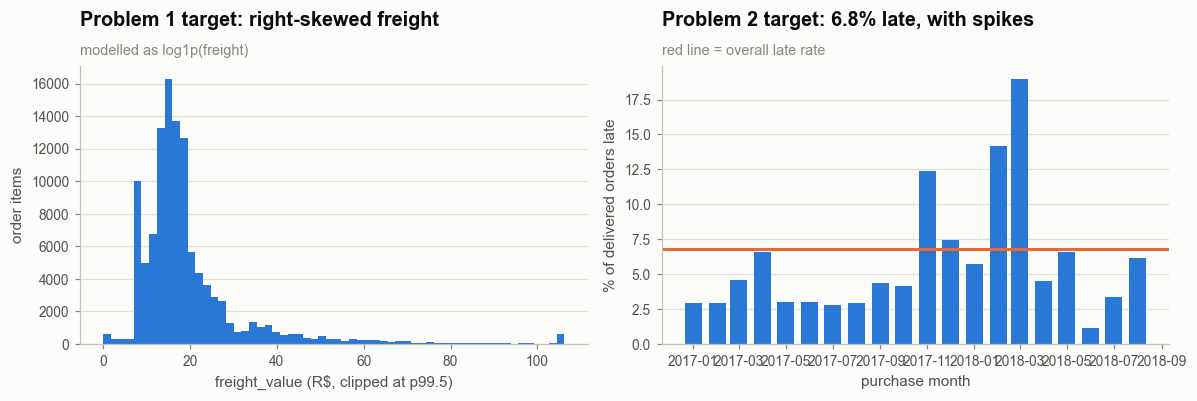

In [4]:
overview = pd.DataFrame({
    "Table": ["Problem 1: order items", "Problem 2: delivered orders"],
    "Rows": [len(items), len(orders)], "Columns": [items.shape[1], orders.shape[1]],
    "Orders": [items.order_id.nunique(), orders.order_id.nunique()],
    "Target": [f"mean freight R${items.freight_value.mean():.2f}", f"late rate {orders.clf_target.mean():.2%}"],
    "Purchase dates": [f"{d.order_purchase_timestamp.min():%Y-%m-%d} to {d.order_purchase_timestamp.max():%Y-%m-%d}"
                       for d in (items, orders)]})
miss = pd.concat([(items.isna().mean() * 100).rename("Problem 1: % missing"),
                  (orders.isna().mean() * 100).rename("Problem 2: % missing")], axis=1)
display(overview, miss[(miss > 0).any(axis=1)].round(2).T.fillna("–"))     # "–": column not in that table
PL.target_overview(items, orders); plt.show()

## 3. Feature engineering and leakage audit

Features are added one group at a time so that Section 5 can test what each adds.

**Problem 1** (nested sets): core drivers (weight, volume, chargeable weight, distance), geography and category, price and basket, listing and timing, and target-encoded seller identity.

**Problem 2** (forward selection): everything is known when the order is placed. Starting from the **delivery promise** (days between purchase and the estimated delivery date, which Olist sets at checkout), these groups are tried in turn:
* **route:** seller-to-customer distance, seller and customer states, and a same-state flag;
* **parcel and product:** total weight, volume, chargeable weight and product category;
* **order value and freight:** total price, total freight, freight-to-price ratio, and numbers of items and sellers;
* **purchase weekday and hour**, and **congestion** (the platform's order volume in the previous 7 days relative to its average week over the 28 days before that, plus the seller's 7-day order count; a ratio is used because raw volume grows with the business);
* **purchase month**, last, as a check. It is not expected to help: only one November has delivered orders (2017), and February–March was late in 2018 (14–19%) but not in 2017 (3–5%), so month marks one-off episodes rather than a season that repeats.

**Why each group (rationale from the Phase 1 report).**

| Problem | Feature group | Why it should matter | Source |
|---|---|---|---|
| 1 | Weight, volume, chargeable weight | Carriers bill on the larger of actual and volumetric weight (volume / 5000, the courier convention); freight correlates 0.61 with weight and 0.59 with volumetric weight | Phase 1 EDA (Section 2.5); logistical variables in Budzyński & Cieśla (2025) |
| 1 | Seller-to-customer distance, same state | Distance is a derived cost driver that raw fields cannot capture; correlation 0.39 with freight | Phase 1 Section 1.3 and EDA; geographical variables in Budzyński & Cieśla (2025) |
| 1 | Category, seller and customer states | Weight, volume, distance and category are the core shipment drivers; the lane fixes the tariff band | Phase 1 Section 1.5 |
| 1 | Price, basket size (items, sellers) | Financial variables; freight is better read relative to item price, and free-shipping programmes shift it | Budzyński & Cieśla (2025); Sun et al. (2024); Fang et al. (2021) |
| 1 | Listing (photos, name and description length), purchase timing | Tests whether transactional and temporal variables add value beyond the core drivers; freight studies use broad input sets | Phase 1 Section 1.5; Kjeldsberg et al. (2026); temporal variables in Budzyński & Cieśla (2025) |
| 1 | Seller identity (target-encoded) | Platform and seller context helps delivery models, but a fair benchmark must not learn a seller's own pricing, or habitual overcharging becomes "expected" | Kandula et al. (2021); Phase 1 Section 1.2 |
| 2 | Promised days | The promise is a managed lever set at checkout (it shapes conversion), and `is_late` is defined against it; delay models use the scheduled shipment time | Cui et al. (2024); Kandula et al. (2021); Wani et al. (2022) |
| 2 | Route: distance, seller and customer states, same state | Transit is most of the lead time (about 9 of 12 days); strong state gradient, São Paulo 4.5% late against Alagoas 21.4% | Phase 1 EDA (Section 2.5) |
| 2 | Parcel and category | Bulky or special items may ship by a different mode; shipping mode and order type predict delays | Wani et al. (2022); Phase 1 Section 1.5 |
| 2 | Order value and freight (incl. freight-to-price ratio) | Financial variables; the freight paid reflects the shipping service bought | Budzyński & Cieśla (2025); Phase 1 Section 1.3 |
| 2 | Purchase weekday and hour | Orders concentrate on weekday business hours; temporal variables | Phase 1 EDA (Section 2.3); Budzyński & Cieśla (2025) |
| 2 | Congestion (platform 7-day surge, seller 7-day load) | Platform-level context and seller shipment volume | Kandula et al. (2021) |
| 2 | Purchase month (check) | Only 2017 has a full year of data, so seasonality cannot be substantiated | Phase 1 EDA (Section 2.3) |

**Problem 1 feature sets** (nested: each set adds one group)

In [5]:
sets_1 = P.feature_set_table(F.FEATURE_SETS)
sets_1

,Feature set,Numeric,Categorical,Target-encoded
0,0 Price only (reference),price,-,-
1,"1 Core (weight, volume, distance)","weight_kg, volume_cm3, chargeable_kg, distance_km",-,-
2,2 + category & states,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state","seller_state, customer_state, category",-
3,3 + price & basket,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers","seller_state, customer_state, category",-
4,4 + listing & timing,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers, photos_qty, name_len, desc_len, purchase_month, purchase_dow, purchase_hour","seller_state, customer_state, category",-
5,5 + seller (target-encoded),"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers, photos_qty, name_len, desc_len, purchase_month, purchase_dow, purchase_hour","seller_state, customer_state, category",seller_id


**Problem 2 starting set and candidate groups** (forward selection, Section 5)

In [6]:
sets_2 = P.feature_set_table({"Start: promise": F.LATE_BASE, **{f"+ {k}": v for k, v in F.LATE_GROUPS.items()}})
sets_2

,Feature set,Numeric,Categorical,Target-encoded
0,Start: promise,promised_days,-,-
1,"+ route (distance, states)","distance_km, same_state","seller_state, customer_state",-
2,+ parcel & category,"weight_kg, volume_cm3, chargeable_kg",category,-
3,+ order value & freight,"price_total, freight_total, freight_ratio, n_items, n_sellers",-,-
4,+ purchase weekday & hour,"purchase_dow, purchase_hour",-,-
5,+ congestion (7-day volume surge),"platform_surge_7d, seller_load_7d",-,-
6,+ purchase month,purchase_month,-,-


**Leakage audit**

| Problem | Field / group | Why it matters | Treatment |
|---|---|---|---|
| 1 | `freight_value` | Is the regression target | Never a predictor |
| 1 | price, weight, dimensions, category, listing text lengths | Fixed on the listing at checkout | Allowed |
| 1 | seller / customer state, zip-centroid distance | Seller listing and buyer address | Allowed |
| 1 | `n_items`, `n_sellers` in the basket; purchase time parts | Known at order placement | Allowed |
| 1 | `seller_id` | Its history uses the target; a fair benchmark would also learn the seller's own overcharging | Tested with a TargetEncoder inside the Pipeline (train folds only); excluded by design |
| 1 | Items of one order | Share basket fields and could straddle a split | Splits and CV grouped by `order_id` |
| 1 | Same product in train and test | A forest can memorise a listing's own past freight | Robustness split grouped by `product_id`; audit uses unseen products |
| 2 | `order_delivered_customer_date` | Defines `is_late`; only known after delivery | Target only, never a predictor |
| 2 | `order_delivered_carrier_date`, `order_approved_at` | Known only after payment clears / the seller ships | Never used |
| 2 | `review_*` columns, `order_status` | Exist only after delivery; status is the final outcome | Never a feature; review score used only to measure business impact |
| 2 | `order_estimated_delivery_date` → `promised_days` | The promise is set and shown at checkout | Allowed (as promised days) |
| 2 | price, freight, weight, distance, category, states, basket, purchase time | Known at order placement | Allowed (tested by forward selection) |
| 2 | `platform_surge_7d`, `seller_load_7d` | Orders placed in the 7 days *before* this purchase (timestamps only) | Allowed (trailing window, no labels); tested, not kept |
| 2 | `purchase_month` | One November only; Feb–Mar late in 2018 (14–19%) but not 2017 (3–5%): marks episodes, not seasons | Tested last in forward selection; not kept |
| 2 | Time ordering | A random split lets the model see the same weeks in train and test | Train on earlier orders, test on the latest 20%, 30-day embargo |

## 4. Train/test discipline

**Problem 1.** 80/20 hold-out **grouped by `order_id`** (items of one order share basket fields) and stratified on target quintiles; 5-fold grouped CV on the training split. A random (grouped) split suits this problem: freight is known at checkout, so there is no label delay, and the use is benchmarking current listings. Drift over time is measured separately with a time-ordered hold-out (Section 11), where MAE rises to R\$5.46 on the latest 20% of items.

**Problem 2 is validated forward in time.** The late rate moves in episodes and Olist's promises changed in 2018, so a random split lets the model see the same weeks in training and test and overstates what it can do on new orders (Section 8 measures by how much). We therefore:
* test on the **latest 20% of orders** by purchase time (from 26 May 2018);
* train on orders placed before that, leaving a **30-day embargo**: at the cut-off, orders from the last few weeks would not yet have been delivered, so their labels could not have been known (95% of orders are delivered within 30 days);
* tune and select with **5-fold forward-chaining CV**: the training orders are cut into six consecutive time blocks and each fold trains on the blocks before its validation block, with the same embargo;
* check the result on **four consecutive test windows** of about three months (Section 10): each is predicted by a model refitted on all orders before it, with the same embargo. The last window is the hold-out above.

Stratification cannot be combined with time ordering; instead every fold's late rate is reported and the metrics are made comparable across folds with **lift** (PR-AUC divided by the fold's late rate; 1 = no skill).

**How to read the evidence.** The forward-chaining CV (five periods from June 2017 to April 2018, late rates 3–13%) and the four windows are the main evidence of skill. The final hold-out is a **stress test**: within it Olist first lengthened its promises sharply (to a median of 37 days in the week of 28 May 2018) and then shortened them to about 13 days from the week of 30 July, and the late rate fell to 3.5%. Because `is_late` is defined against the promise, that window measures how the model copes with a policy change, not its typical skill.

**Split sizes, targets and overlap checks**

In [7]:
strat_a = pd.qcut(items.reg_target.rank(method="first"), 5, labels=False)      # freight quintiles
tr_a, te_a = M.holdout_split(items, strat_a)
tr_b, te_b = M.time_holdout(orders)
assert not set(tr_a.order_id) & set(te_a.order_id) and not set(tr_b.order_id) & set(te_b.order_id), "orders leaked across a split"
assert tr_b.purchase_ts.max() < te_b.purchase_ts.min() - F.EMBARGO_DAYS * M.DAY, "embargo violated"
splits = P.split_summary(tr_a, te_a, tr_b, te_b)
splits

,Split,Rows,Orders,Target,Purchase dates,Check
0,1 train,90120,78932,mean freight R$20.01,2016-09-04 to 2018-09-03,
1,1 test,22530,19734,mean freight R$19.93,2016-09-05 to 2018-08-29,77.8% of test items' products also in train
2,2 train,70241,70241,late rate 7.7%,2016-09-15 to 2018-04-26,30-day embargo before the test window
3,2 test,19295,19295,late rate 3.5%,2018-05-26 to 2018-08-29,2.0% of test orders from a customer also in train


**Problem 2 forward-chaining folds** (training split only)

In [8]:
folds = P.cv_fold_table(tr_b)
folds

,Fold,Train dates,Train orders,Train late rate,Validation dates,Validation orders,Validation late rate
0,1,2016-09-15 to 2017-05-07,8217,0.044,2017-06-06 to 2017-09-10,11707,0.030
1,2,2016-09-15 to 2017-08-11,19509,0.035,2017-09-10 to 2017-11-24,11707,0.059
2,3,2016-09-15 to 2017-10-25,29997,0.036,2017-11-24 to 2018-01-15,11707,0.091
3,4,2016-09-15 to 2017-12-16,41649,0.057,2018-01-15 to 2018-03-05,11707,0.132
4,5,2016-09-15 to 2018-02-03,51388,0.056,2018-03-05 to 2018-04-26,11706,0.108


## 5. Feature-set selection (training data only)

Does each added feature group earn its place? This also answers the Phase 1 question of whether seller, customer and timing variables add value beyond the core shipment drivers.
* **Problem 1:** a fast RandomForest, 3-fold grouped CV on a 40,000-row training sub-sample; each group is judged by its **paired gain** (the drop in MAE over the previous set, fold by fold) against the fold standard deviation of that gain.
* **Problem 2:** forward selection on forward-chaining CV with both base families (a fixed L2 logistic model and a fixed regularised forest). Starting from the promise, each group is added to the set kept so far; because the folds differ a lot in difficulty, it is judged by its **paired gain** in lift over that set, fold by fold, and kept only if the gain exceeds its fold standard deviation for at least one family.

**Problem 1: freight regression** (3-fold grouped CV; MAE in R\$; gain = paired drop in MAE vs the previous set)

,Feature set,MAE (R$),RMSE (R$),R2 (R$),Gain (R$),Gain sd
0,0 Price only (reference),7.432,14.526,0.177,NaN,NaN
1,"1 Core (weight, volume, distance)",4.437,9.760,0.628,2.995,0.052
2,2 + category & states,4.017,9.161,0.673,0.419,0.030
3,3 + price & basket,3.858,8.920,0.690,0.159,0.017
4,4 + listing & timing,3.782,8.907,0.691,0.076,0.028
5,5 + seller (target-encoded),3.753,8.889,0.692,0.029,0.007


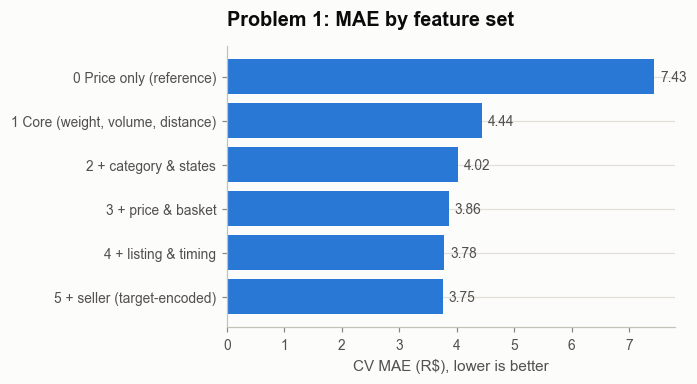

In [9]:
ab_a = P.ablation_regression(tr_a)
display(ab_a); PL.ablation_chart_reg(ab_a); plt.show()
fs_a = F.FEATURE_SETS[F.FULL_SET]                  # Problem 1 modelling set (see the text below)

**Problem 2: is_late, forward selection** (forward-chaining CV; lift = PR-AUC / late rate; gain = paired change vs the set kept so far)

,Feature set,Logit lift,Logit gain,Logit gain sd,Logit ROC-AUC,RF lift,RF gain,RF gain sd,RF ROC-AUC,Kept
0,Promise only (start),0.969,NaN,NaN,0.501,0.996,NaN,NaN,0.504,start
1,"+ route (distance, states)",1.970,1.001,0.433,0.677,1.807,0.811,0.353,0.656,yes
2,+ parcel & category,1.930,-0.040,0.065,0.673,1.804,-0.003,0.058,0.656,no
3,+ order value & freight,2.028,0.058,0.071,0.690,1.852,0.045,0.033,0.658,yes
4,+ purchase weekday & hour,2.023,-0.005,0.023,0.687,1.843,-0.009,0.026,0.656,no
5,+ congestion (7-day volume surge),1.993,-0.035,0.097,0.686,1.579,-0.273,0.278,0.621,no
6,+ purchase month,1.922,-0.105,0.207,0.672,1.637,-0.215,0.231,0.634,no
7,Re-check: + parcel & category,1.992,-0.035,0.039,0.682,1.819,-0.032,0.032,0.653,no


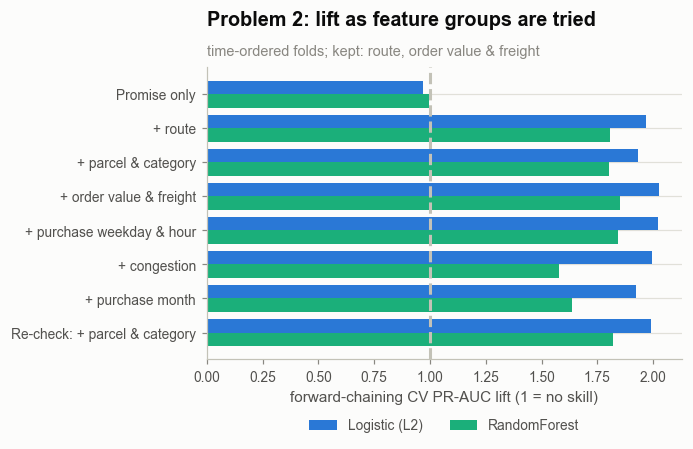

In [10]:
ab_b, fs_b = P.ablation_classification(tr_b)       # fs_b: the feature set the forward selection keeps
display(ab_b); PL.ablation_chart_clf(ab_b); plt.show()
cols_a, cols_b = P.cols_for(fs_a), P.cols_for(fs_b)

**Problem 1 (freight).** Weight, volume and distance cut CV MAE from R\$7.43 (price alone) to R\$4.44 (paired gain R\$2.99 ± 0.05). Category and states bring it to R\$4.02 (+0.42 ± 0.03), price and basket to R\$3.86 (+0.16 ± 0.02), and listing and timing to R\$3.78 (+0.08 ± 0.03); each gain exceeds its fold sd. Target-encoded seller identity also clears the rule (+R\$0.03 ± 0.01), but the gain is under 1% of MAE and it is **excluded by design**: a fair-freight benchmark must not learn each seller's own pricing, or a seller's habitual overcharging becomes "expected" freight and the audit (Section 11) cannot see it (Phase 1 Section 1.2). The modelling set is **"4 + listing & timing"**.

**Problem 2 (is_late), forward selection.** The promise alone has no skill (lift 0.97 / 1.00). **Route information doubles the lift** (paired gain +1.00 ± 0.43 for the logistic model, +0.81 ± 0.35 for the forest) and is kept. **Parcel and category adds nothing** (−0.04 ± 0.07 and −0.00 ± 0.06) and is dropped. **Order value and freight** is kept: its gain exceeds its fold sd for the forest (+0.04 ± 0.03; +0.06 ± 0.07 for the logistic model). The timing groups do not transfer to later periods:
* purchase weekday and hour: about 0 (−0.005 logistic, −0.009 forest);
* the congestion ratio: −0.03 (logistic) and −0.27 (forest);
* **adding purchase month lowers lift** (−0.11 logistic, −0.22 forest), confirming that it encodes episodes, not seasons.

Re-tried against the final set (the "Re-check" row), parcel and category still adds nothing (−0.04 logistic, −0.03 forest), so the order in which the groups are tried does not decide the result. The modelling set is therefore **promised days, route, and order value and freight**. Calendar and congestion signals can only help a model that has already seen the same weeks, which a random split allows and a forward split does not (Section 8 shows how much a random split flatters the flexible models).

## 6. Models, baselines and hyper-parameter tuning

| Family | Baseline (simplest) | Tuned / advanced |
|---|---|---|
| Linear | `LinearRegression`, plain `LogisticRegression` (no penalty) | `Ridge(alpha)`, `LogisticRegression(C, class_weight)` |
| Tree-based | `DecisionTree` (lightly constrained: min leaf 5 / 20, otherwise default) | `RandomForest` (leaf size, max features, depth; class weight for Problem 2) |
| Ensemble | the better of its two members | Problem 1: `Stacking` (Ridge + RandomForest → Ridge, inner 3-fold grouped CV). Problem 2: soft `Voting` (Logistic + RandomForest, tuned weight) |

A mean (Problem 1) or class-prior (Problem 2) dummy is the no-skill floor.

**Why voting rather than stacking for Problem 2.** A stacking meta-learner is trained on out-of-fold predictions for every training row, which a forward-in-time scheme cannot supply without predicting earlier orders from later ones. Soft voting needs no inner fit; its single weight is tuned on the same forward-chaining folds. Weighted voting is also the design Wani et al. (2022) used for delivery-delay prediction (Phase 1 literature review).

**Tuning.** Problem 1: full grid for Ridge `alpha`, randomised search (8 of 36 combinations) for the forest on a grouped sub-sample, 5-fold grouped CV, scored by MAE. Problem 2: full grid for Logistic `C` × `class_weight`, randomised search (20 of 240 combinations) for the forest on all training orders, grid for the voting weight; all on 5-fold forward-chaining CV, scored by **PR-AUC lift**.

**Handling imbalance in Problem 2 (metric, decision rule and tuned class weights; no resampling).** PR-AUC lift is the tuning and selection score, and `class_weight` (none / balanced / balanced-subsample) is a tuned hyper-parameter. We avoid SMOTE-style resampling because it distorts probability calibration (van den Goorbergh et al., 2022; Phase 1 literature review). In the event the tuning kept class weights only for the forest: the L2 logistic model ranked best without them, and plain logistic regression, the final model, is unweighted. For the final model, imbalance is therefore handled by what we measure (PR-AUC lift) and how we act (flag a fixed share of orders, which needs no probability threshold).

**From a risk score to a flag.** Precision, recall and F1 need a line between "flagged" and "not flagged". Because the late rate drifts from 1% to 19% by month, a fixed probability cut-off would flag almost nothing in some months and far too much in others. We therefore flag the **riskiest 10% of orders**, assuming the operations team can check about one order in ten; Section 10 shows what larger review shares would catch.

**Tuning results** (best hyper-parameters and their CV score)

In [11]:
best_a, tune_a = P.tune_regression(tr_a, fs_a)
best_b, tune_b = P.tune_classification(tr_b, fs_b)
tuning = pd.concat([tune_a, tune_b], ignore_index=True)
tuning

,Problem,Model,Search,Best params,CV score,Scored by
0,1 Regression,Ridge,grid (6),{'m__alpha': 10},0.198,MAE (log)
1,1 Regression,RandomForest,random (8 of 36),"{'m__n_estimators': 100, 'm__min_samples_leaf': 2, 'm__max_features': 0.33, 'm__max_depth': 16}",0.159,MAE (log)
2,2 is_late,Logistic (L2),grid (8),"{'m__C': 0.1, 'm__class_weight': None}",2.028,PR-AUC lift
3,2 is_late,RandomForest,random (20 of 240),"{'m__n_estimators': 100, 'm__min_samples_leaf': 100, 'm__max_features': 'sqrt', 'm__max_depth': None, 'm__class_weight': 'balanced'}",1.860,PR-AUC lift
4,2 is_late,Voting (Logit + RF),grid (3),{'w_logit': 0.75},1.991,PR-AUC lift


## 7. Cross-validation (on each training split)

**Problem 1 — regression, 5-fold grouped CV** (mean and sd across folds)

In [12]:
reg_models = P.final_reg_models(fs_a, best_a)
clf_models = P.final_clf_models(fs_b, best_b)
cv_a = P.cv_regression(reg_models, tr_a, fs_a)
cv_a

,Model,MAE_rs mean,RMSE_rs mean,R2_rs mean,R2_log mean,MAE_rs sd,RMSE_rs sd,R2_rs sd
0,Mean predictor (dummy),7.811,16.049,-0.036,-0.000,0.087,0.350,0.002
1,Linear: LinearRegression,4.743,10.873,0.525,0.588,0.098,0.401,0.015
2,Linear: Ridge,4.743,10.877,0.525,0.588,0.098,0.402,0.015
3,Tree: DecisionTree (baseline),4.382,9.767,0.616,0.598,0.064,0.204,0.009
4,Tree: RandomForest,3.583,8.317,0.722,0.732,0.078,0.403,0.015
5,Ensemble: Stacking (Ridge + RF),3.589,8.202,0.730,0.732,0.073,0.392,0.015


**Problem 2 — is_late, 5-fold forward-chaining CV** (mean and sd; precision, recall and F1 for the riskiest 10% of orders in each validation block)

In [13]:
cv_b, share_b = P.cv_classification(clf_models, tr_b, fs_b)
cv_b

,Model,Precision mean,Recall mean,F1 mean,ROC_AUC mean,PR_AUC mean,Lift mean,F1 sd,PR_AUC sd,Lift sd
0,Prior predictor (dummy),0.082,0.095,0.084,0.500,0.084,1.000,0.031,0.040,0.000
1,Linear: LogisticRegression (plain),0.212,0.243,0.215,0.682,0.174,2.010,0.098,0.102,0.339
2,Linear: Logistic (L2),0.215,0.246,0.218,0.690,0.178,2.028,0.099,0.107,0.353
3,Tree: DecisionTree (baseline),0.138,0.157,0.140,0.554,0.111,1.286,0.062,0.062,0.177
4,Tree: RandomForest,0.201,0.231,0.204,0.657,0.164,1.882,0.091,0.098,0.336
5,Ensemble: Voting (Logit + RF),0.216,0.251,0.220,0.675,0.174,2.000,0.095,0.105,0.370


## 8. Held-out test evaluation and model selection

**Problem 1 — held-out test set** (R\$ metrics on the original scale; `*_log` on the modelled log1p scale)

,Model,MAE_rs,RMSE_rs,R2_rs,MAE_log,RMSE_log,R2_log
0,Mean predictor (dummy),7.742,16.197,-0.033,0.356,0.526,-0.000
1,Linear: LinearRegression,4.738,11.068,0.518,0.199,0.343,0.574
2,Linear: Ridge,4.738,11.070,0.517,0.199,0.343,0.574
3,Tree: DecisionTree (baseline),4.376,9.947,0.610,0.182,0.328,0.610
4,Tree: RandomForest,3.552,8.452,0.719,0.150,0.273,0.731
5,Ensemble: Stacking (Ridge + RF),3.545,8.286,0.730,0.150,0.271,0.734


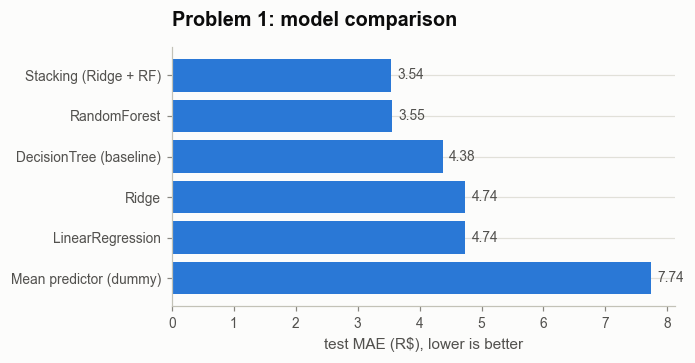

In [14]:
fit_a = P.fit_all(reg_models, tr_a, "reg_target", fs_a)
test_a = P.test_regression(fit_a, te_a, fs_a)
display(test_a); PL.comparison_chart_reg(test_a); plt.show()

**Problem 2 — time-ordered test set** (orders from 26 May 2018; late rate 3.5%; riskiest 10% of orders flagged)

In [15]:
fit_b = P.fit_all(clf_models, tr_b, "clf_target", fs_b)
test_b = P.test_classification(fit_b, te_b, fs_b, share_b)
test_b

,Model,Flagged,Precision,Recall,F1,BalancedAcc,ROC_AUC,PR_AUC,Lift,Brier
0,Prior predictor (dummy),0.100,0.031,0.088,0.045,0.494,0.500,0.035,1.000,0.035
1,Linear: LogisticRegression (plain),0.100,0.080,0.228,0.118,0.567,0.672,0.070,1.998,0.041
2,Linear: Logistic (L2),0.100,0.077,0.221,0.114,0.563,0.666,0.069,1.979,0.041
3,Tree: DecisionTree (baseline),0.100,0.045,0.129,0.067,0.515,0.634,0.056,1.615,0.054
4,Tree: RandomForest,0.100,0.049,0.139,0.072,0.520,0.524,0.041,1.179,0.221
5,Ensemble: Voting (Logit + RF),0.100,0.068,0.196,0.101,0.550,0.618,0.062,1.762,0.061


**Problem 2 — the same models on a random split** (grouped by `customer_unique_id`, late rate 6.8%) **vs the time-ordered test**

,Model,Random PR-AUC,Random lift,Random ROC-AUC,Time-ordered PR-AUC,Time-ordered lift,Time-ordered ROC-AUC
0,Prior predictor (dummy),0.068,1.000,0.500,0.035,1.000,0.500
1,Linear: LogisticRegression (plain),0.147,2.168,0.706,0.070,1.998,0.672
2,Linear: Logistic (L2),0.145,2.143,0.705,0.069,1.979,0.666
3,Tree: DecisionTree (baseline),0.110,1.622,0.606,0.056,1.615,0.634
4,Tree: RandomForest,0.151,2.234,0.709,0.041,1.179,0.524
5,Ensemble: Voting (Logit + RF),0.150,2.210,0.712,0.062,1.762,0.618


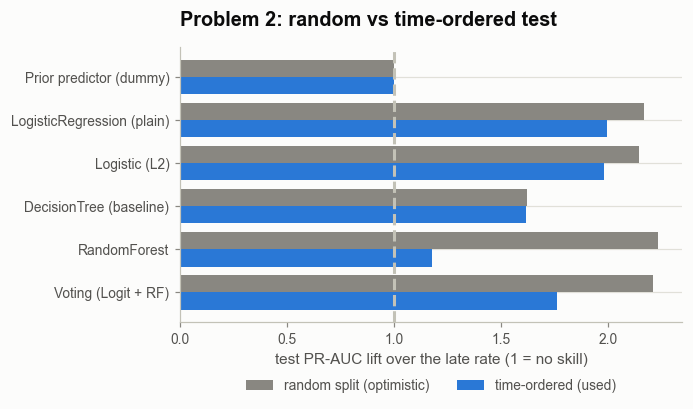

In [16]:
cmp_b, rand_rate = P.split_comparison(clf_models, orders, fs_b, test_b)
display(cmp_b); PL.comparison_chart_clf(cmp_b); plt.show()

In [17]:
# Final model per problem: the simplest model within one fold sd of the best mean CV score
FINAL_A = P.pick_final(cv_a, "MAE_rs mean", "MAE_rs sd", False, P.ORDER_A)
FINAL_B = P.pick_final(cv_b, "Lift mean", "Lift sd", True, P.ORDER_B)
print("Final model, Problem 1:", FINAL_A, "| Problem 2:", FINAL_B)

Final model, Problem 1: Tree: RandomForest | Problem 2: Linear: LogisticRegression (plain)


**Baseline vs advanced model in each family** (CV; gain > 0 = advanced better; an advanced model is kept only if its gain exceeds one fold sd). Problem 1, MAE in R\$:

In [18]:
bva_a = P.baseline_vs_advanced(cv_a, test_a, P.PAIRS_A, "MAE_rs mean", "MAE_rs sd", "MAE_rs", higher=False)
bva_a

,Comparison,Baseline,Advanced,Baseline CV,Advanced CV,CV gain,Fold sd,Test gain,Verdict
0,Linear,Linear: LinearRegression,Linear: Ridge,4.743,4.743,0.001,0.098,0.000,no better than baseline (within 1 sd)
1,Tree-based,Tree: DecisionTree (baseline),Tree: RandomForest,4.382,3.583,0.798,0.078,0.824,advanced better (gain > 1 sd)
2,Linear vs tree,Linear: Ridge,Tree: RandomForest,4.743,3.583,1.159,0.078,1.186,advanced better (gain > 1 sd)
3,Ensemble vs its better member,Tree: RandomForest,Ensemble: Stacking (Ridge + RF),3.583,3.589,-0.005,0.078,0.007,no better than baseline (within 1 sd)


Problem 2, PR-AUC lift:

In [19]:
bva_b = P.baseline_vs_advanced(cv_b, test_b, P.PAIRS_B, "Lift mean", "Lift sd", "Lift", higher=True)
bva_b

,Comparison,Baseline,Advanced,Baseline CV,Advanced CV,CV gain,Fold sd,Test gain,Verdict
0,Linear,Linear: LogisticRegression (plain),Linear: Logistic (L2),2.010,2.028,0.018,0.353,-0.018,no better than baseline (within 1 sd)
1,Tree-based,Tree: DecisionTree (baseline),Tree: RandomForest,1.286,1.882,0.595,0.336,-0.437,advanced better (gain > 1 sd)
2,Linear vs tree,Linear: Logistic (L2),Tree: RandomForest,2.028,1.882,-0.146,0.353,-0.801,no better than baseline (within 1 sd)
3,Ensemble vs its better member,Linear: Logistic (L2),Ensemble: Voting (Logit + RF),2.028,2.000,-0.027,0.353,-0.217,no better than baseline (within 1 sd)


**Baseline vs advanced, per family.** In Problem 1 one step up in complexity clears the one-sd bar: the forest beats its single tree by R\$0.80 of CV MAE (10 fold sds) and Ridge by R\$1.16, while Ridge adds nothing to LinearRegression (R\$0.001) and stacking nothing to the forest (−R\$0.005). In Problem 2 the forest beats the single tree in CV (+0.60 lift, 1.8 fold sds) but not on the test window (−0.44), and nothing beats the logistic baseline: L2 regularisation +0.02 (fold sd 0.35), the forest −0.15 against L2 logistic, the vote −0.03 against its better member.

**Train vs validation vs test.** Train = each model fitted on the whole training split and scored on those same rows; validation = mean over the CV folds (Section 7); test = the held-out set. Problem 1, R\$:

In [20]:
tvt_a = P.train_val_test_regression(fit_a, tr_a, fs_a, cv_a, test_a)
tvt_a

,Model,Train MAE,CV MAE,Test MAE,CV - train MAE,Train R2,CV R2,Test R2
0,Mean predictor (dummy),7.811,7.811,7.742,0.000,-0.036,-0.036,-0.033
1,Linear: LinearRegression,4.730,4.743,4.738,0.013,0.527,0.525,0.518
2,Linear: Ridge,4.730,4.743,4.738,0.013,0.527,0.525,0.517
3,Tree: DecisionTree (baseline),2.204,4.382,4.376,2.178,0.875,0.616,0.610
4,Tree: RandomForest,2.644,3.583,3.552,0.939,0.865,0.722,0.719
5,Ensemble: Stacking (Ridge + RF),2.582,3.589,3.545,1.006,0.878,0.730,0.730


Problem 2 (lift = PR-AUC / late rate, because the late rate is 7.7% in training, 3–13% across the CV blocks and 3.5% in the test window):

In [21]:
tvt_b = P.train_val_test_classification(fit_b, tr_b, fs_b, cv_b, test_b)
tvt_b

,Model,Train lift,CV lift,Test lift,Train - CV lift,Train ROC-AUC,CV ROC-AUC,Test ROC-AUC
0,Prior predictor (dummy),1.000,1.000,1.000,0.000,0.500,0.500,0.500
1,Linear: LogisticRegression (plain),2.444,2.010,1.998,0.434,0.720,0.682,0.672
2,Linear: Logistic (L2),2.438,2.028,1.979,0.410,0.719,0.690,0.666
3,Tree: DecisionTree (baseline),4.826,1.286,1.615,3.540,0.890,0.554,0.634
4,Tree: RandomForest,2.867,1.882,1.179,0.985,0.749,0.657,0.524
5,Ensemble: Voting (Logit + RF),2.581,2.000,1.762,0.581,0.739,0.675,0.618


**What the train / validation / test tables show.** Problem 1: the linear models score the same on their training rows, in CV and on the test set (MAE R\$4.73 / 4.74 / 4.74), so they do not overfit; their error is high because a linear tariff underfits the freight structure. The single tree overfits (training MAE R\$2.20 against R\$4.38 in CV). The forest also fits its own training rows more closely (R\$2.64), as expected for trees grown on those rows, but its CV and test MAE agree (R\$3.58 and R\$3.55), so the CV estimate is reliable and the test result is not luck. Problem 2: plain logistic regression has a small gap (lift 2.44 on its training orders, 2.01 in CV, 2.00 on the test window; ROC-AUC 0.72 / 0.68 / 0.67). The trees memorise the training period: the single tree's lift falls from 4.83 to 1.29 in CV, and the forest's from 2.87 to 1.88 in CV and 1.18 on the test window. This is the same overfitting that the random-split comparison exposes, and the logistic model's small gap is why it transfers to later orders.

### 8.1 Model selection and ensemble justification
**Problem 1, regression: final model = RandomForest.**
Test MAE is R\$3.55 against R\$4.74 for Ridge, R\$4.38 for the DecisionTree baseline and R\$7.74 for the mean predictor; test R² is 0.719 against 0.517 and 0.610. In 5-fold CV the forest's MAE is 3.58 ± 0.08 against 4.74 ± 0.10 for Ridge, a gap of R\$1.16, more than ten fold standard deviations. The complexity ladder is justified: the forest beats its single-tree baseline by R\$0.80 and the linear family by R\$1.16. Ridge is indistinguishable from plain LinearRegression (4.743 vs 4.743 CV MAE), so regularisation adds nothing. Stacking ties the forest (CV MAE 3.589 vs 3.583; test 3.545 vs 3.552) with a slightly lower RMSE (test 8.29 vs 8.45; CV 8.20 vs 8.32 with a fold sd of 0.39–0.40, so within fold noise), so by the one-sd rule the single forest is kept and stacking is reported as a negative result.

**Problem 2, is_late: final model = plain LogisticRegression.**
In forward-chaining CV the L2 logistic model has the highest mean lift (2.03 ± 0.35), followed by plain logistic (2.01 ± 0.34), the soft vote (2.00 ± 0.37), RandomForest (1.88 ± 0.34) and the DecisionTree (1.29 ± 0.18). Every model except the single tree lies within one fold sd of the best, so the one-sd rule keeps the **simplest**, plain logistic regression. Within the tree family the forest does improve on its single-tree baseline (+0.60 lift, 1.8 fold sds), but it never overtakes the linear models.

The four test windows (Section 10) agree: logistic models lead the forest in every window, and plain logistic regression's lift is 1.47, 1.71, 2.24 and 2.00 (mean 1.85), always above chance; it rises from W1 to W3 as more history accumulates and holds in the stress test. L2 logistic edges it by at most 0.10 (W2), within the CV noise.

**Stress test (final hold-out, 26 May to 29 August 2018, late rate 3.5%).** Plain logistic regression keeps its skill through the promise changes: PR-AUC 0.070 (**lift 2.00**, ROC-AUC 0.672), ahead of L2 logistic (1.98), the vote (1.76), the DecisionTree (1.62) and the RandomForest (1.18). Flagging the riskiest 10% of orders gives precision 0.080, recall 0.228 and F1 0.118, against 0.031 / 0.088 / 0.045 for random review of the same 10%. Within the window its lift falls from 6.4 in June to 1.2 in August, after promises were cut to about 13 days (Section 10).

**Why the simplest model wins: random vs time-ordered evaluation.** Refitting the same specifications on a random split (grouped by customer) shows the cost of ignoring time. Plain logistic regression barely moves (lift 2.17 random vs 2.00 time-ordered), but the forest falls from 2.23 to 1.18. The models have no calendar features, but flexible ones pick up period-specific patterns through other inputs (for example the promise lengths and order mixes typical of the late weeks of November 2017 and February–March 2018), and a random split rewards them for recognising the same periods in the test set.

**Ensemble: soft voting, tested and not selected.** The weighted vote (weight 0.75 on the logistic model, tuned forward in time) does not beat its better member: CV lift 2.00 against 2.03 for L2 logistic (fold sd 0.35), and 1.76 against 1.98 on the test window. It follows the weighted-voting design of Wani et al. (2022), who found that weighting the members of a voting classifier beats equal weights; here the forest member adds period-specific signal that does not transfer, so the vote is reported as a negative result.

**Success criteria.** Problem 1: test MAE R\$3.55 is 17.8% of mean freight, under the 20% target, and beats both baselines; on never-seen listings it is R\$4.04 (20.3%), at the limit (Section 11). Problem 2: lift 2.00 exceeds the 1.5 target, and no more complex model beat the plain logistic baseline, so the baseline itself is the final model. Flagging the riskiest 10% of orders catches 22.8% of late orders in the stress test, so the 20% recall target is met there, and 18–29% across the four windows, meeting it in 3 of 4 (W2–W4; Section 10). Lift exceeds 1.5 in 3 of the 4 windows (W1: 1.47).

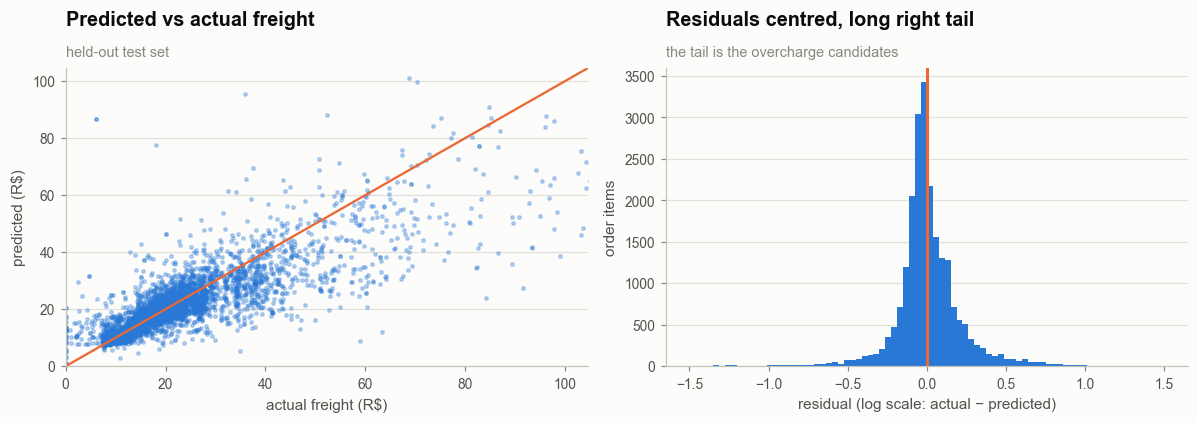

In [22]:
pred_a = fit_a[FINAL_A].predict(te_a[cols_a])
PL.pred_vs_actual(te_a.reg_target, pred_a); plt.show()

Predictions follow the diagonal for typical freight and fall short for the most expensive shipments (points under the line on the right), the usual pull towards the mean. On the log scale the residuals are centred on zero with a longer right tail: items charged well above what the model expects, which Section 11 audits.

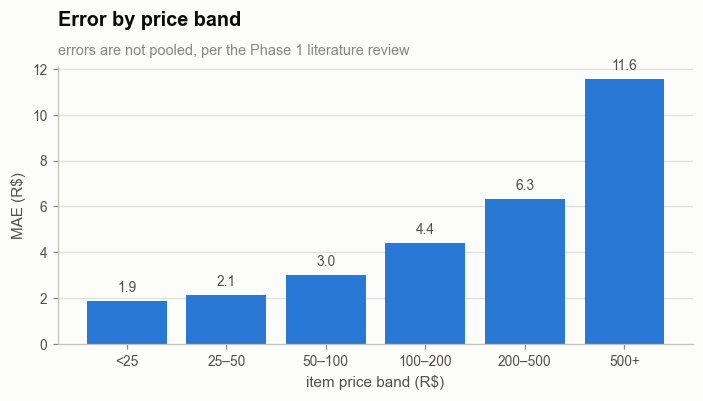

,MAE,MAE % of mean freight,n
band,,,
<25,1.890,13.710,2784
25–50,2.140,13.916,5131
50–100,3.034,16.850,6604
100–200,4.411,19.354,5337
200–500,6.348,21.067,2053
500+,11.550,24.441,621


In [23]:
band = PL.error_by_price_band(te_a, pred_a)
plt.show(); band

MAE grows with item price, from R\$1.9 (13.7% of mean freight) for items under R\$25 to R\$11.6 (24.4%) above R\$500, so one tolerance band would be too tight for expensive items (Section 12, insight 8).

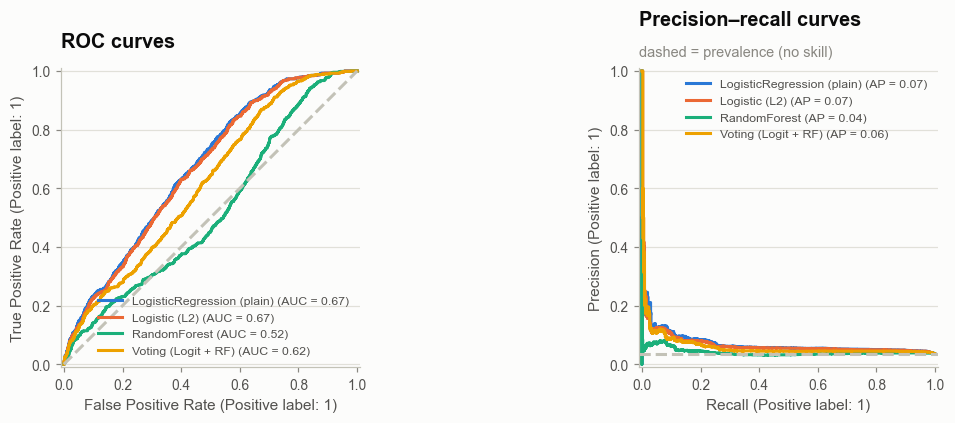

In [24]:
CURVES = ["Linear: LogisticRegression (plain)", "Linear: Logistic (L2)", "Tree: RandomForest", "Ensemble: Voting (Logit + RF)"]
PL.clf_curves(fit_b, te_b, cols_b, te_b.clf_target, names=CURVES); plt.show()

On the stress-test window the two logistic models trace almost the same curves (ROC-AUC 0.67), the vote sits below them and the forest is close to the diagonal (0.52). Precision is low at every recall level because only 3.5% of these orders are late.

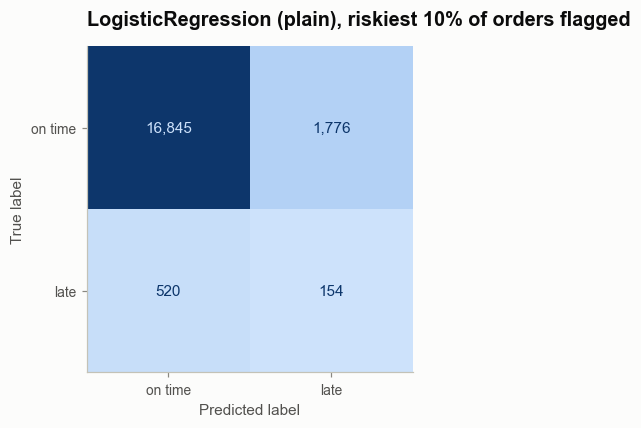

In [25]:
score_b = M.clf_scores(fit_b[FINAL_B], te_b[cols_b])
flags_b = M.flag_top_share(score_b, share_b[FINAL_B])
TITLE_B = f"{FINAL_B.split(': ')[-1]}, riskiest {share_b[FINAL_B]:.0%} of orders flagged"
PL.confusion(te_b.clf_target, flags_b, title=TITLE_B); plt.show()

Flagging the riskiest 10% (1,930 orders) catches 154 of the 674 late orders and raises 1,776 false alarms among 18,621 on-time orders: about one late order per 13 flags, so the follow-up action must be cheap (Section 12, insight 1).

### 8.2 Problem 2: which late orders are missed?
Overall recall hides where the misses are. The late orders of the stress-test window, split by the promise shown at checkout and by the customer's region (final model, riskiest 10% of orders flagged):

,Breakdown,Group,Orders,Late orders,Late rate,Flagged share,Caught,Precision,Recall,Share of missed late orders
0,Promised days,< 14,5395,427,0.079,0.083,57,0.127,0.133,0.712
1,Promised days,14-20,4637,121,0.026,0.181,61,0.073,0.504,0.115
2,Promised days,21-27,4330,82,0.019,0.121,32,0.061,0.390,0.096
3,Promised days,28-34,2670,31,0.012,0.042,4,0.036,0.129,0.052
4,Promised days,35+,2263,13,0.006,0.004,0,0.000,0.000,0.025
5,Customer region,São Paulo,8922,405,0.045,0.011,21,0.221,0.052,0.738
6,Customer region,Rest of Southeast,4706,104,0.022,0.160,47,0.063,0.452,0.110
7,Customer region,South,2537,44,0.017,0.101,12,0.047,0.273,0.062
8,Customer region,Central-West,1102,36,0.033,0.085,18,0.191,0.500,0.035
9,Customer region,North & Northeast,2028,85,0.042,0.361,56,0.076,0.659,0.056


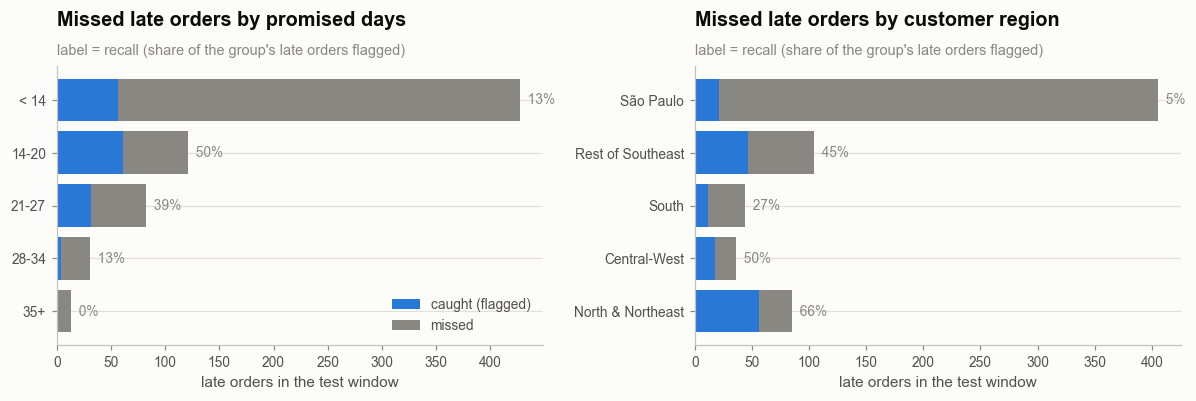

In [26]:
miss_b = P.missed_late_orders(te_b, flags_b)
display(miss_b); PL.missed_late_chart(miss_b); plt.show()

**The misses are concentrated, and they follow the change in promise rules.** 71% of the missed late orders had a promise under 14 days and 74% went to São Paulo customers, and the two largely coincide: half of the window's late orders (340 of 674) were São Paulo orders promised under 14 days, the model flagged only 3% of them, and they make up 63% of all missed late orders. In training such orders were relatively safe (4.6% late, against 7.7% overall); in the test window 7.9% of them were late, more than twice the window's 3.5%, and they grew from none of the orders in May 2018 to 38% in August, as Olist shortened its promises. The model still ranks by the training-period geography: it catches 66% of late orders in the North and Northeast, which were risky in training, but 5% in São Paulo, where the late rate stayed at 4.5% while every other region fell to 1.7–4.2%. Consistently, shuffling distance or the same-state flag *raises* PR-AUC on this window (negative permutation importance, Section 9): the route signal learned in training points the wrong way here. Outside the São Paulo short-promise group, the same top-10% rule catches 43% of late orders. The ranking therefore fails exactly where the promise policy changed, which is why re-training after such a change matters (Section 12, insight 3).

## 9. Feature importance and interpretability

Permutation importance of the final models on the test sets (on the raw columns, so one-hot groups are not split) and standardised coefficients of the linear models. For Problem 2 we read the coefficients of the **L2** logistic model: with a full one-hot encoding the unpenalised model's state coefficients are not identifiable (only their differences are), while the penalty makes them stable; its CV lift is within 0.02 of the plain model.

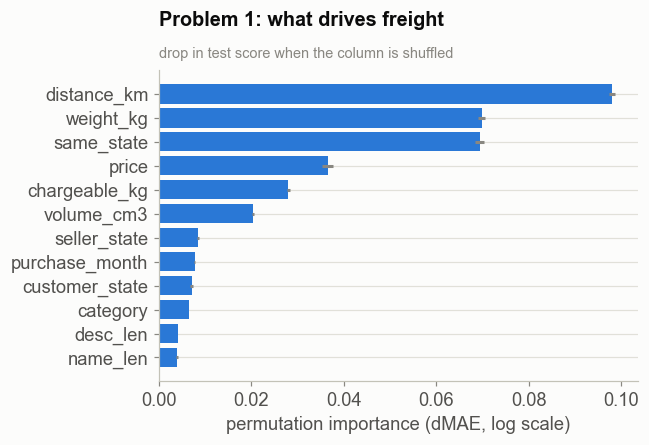

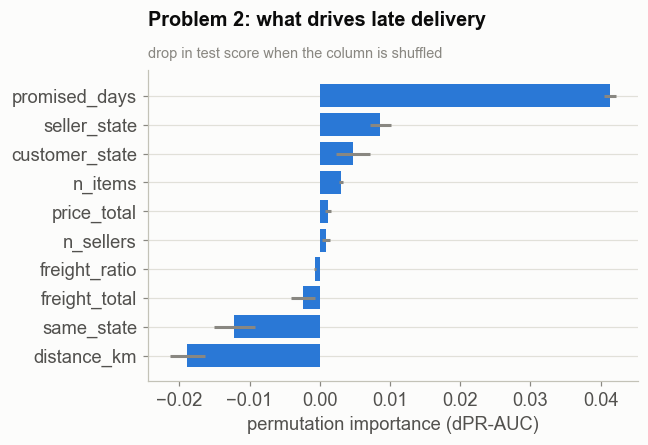

In [27]:
imp_a = P.perm_importance(fit_a[FINAL_A], te_a, fs_a, "reg_target")
imp_b = P.perm_importance(fit_b[FINAL_B], te_b, fs_b, "clf_target")
PL.importance_bar(imp_a, "Problem 1: what drives freight", unit="(dMAE, log scale)"); plt.show()
PL.importance_bar(imp_b, "Problem 2: what drives late delivery", unit="(dPR-AUC)"); plt.show()

**Top standardised coefficients: Ridge** (log freight)

In [28]:
ridge_coefs = P.linear_coefs(fit_a["Linear: Ridge"])
ridge_coefs

,feature,coef
0,category_furniture_mattress_and_upholstery,0.439
1,customer_state_RR,0.278
2,customer_state_RO,0.261
3,customer_state_SP,-0.255
4,category_kitchen_dining_laundry_garden_furniture,0.234
5,customer_state_PB,0.230
6,seller_state_MS,-0.224
7,customer_state_AC,0.223
8,customer_state_MA,0.223
9,customer_state_RS,-0.222


**Top standardised coefficients: L2 logistic** (log-odds of late)

In [29]:
logit_coefs = P.linear_coefs(fit_b["Linear: Logistic (L2)"])
logit_coefs

,feature,coef
0,customer_state_AL,0.907
1,customer_state_PR,-0.824
2,customer_state_MG,-0.769
3,promised_days,-0.723
4,customer_state_DF,-0.667
5,seller_state_RS,-0.567
6,customer_state_SP,-0.558
7,seller_state_BA,-0.501
8,customer_state_PA,0.484
9,seller_state_MA,0.473


## 10. Problem 2 over time: test windows, the stress test and customer satisfaction

The ops team cannot intervene on every order. Ranking orders by predicted risk shows how many late orders a limited review reaches. We check this four ways: on the final hold-out as a whole, month by month within it, across four consecutive test windows, and against the outcome the business ultimately cares about, the review score.

**Several test windows.** Each window (about three months) is predicted by the same specifications refitted on all orders before it, minus the 30-day embargo. The model specification (features and hyper-parameters) was chosen on data up to April 2018, so W1–W3 are consistency checks rather than untouched tests; only W4, the final hold-out, is fully untouched.

**Link to satisfaction.** Reviews are never a feature (they are written after the outcome), but they let us ask whether the orders the model flags go on to receive more 1–2 star reviews.

**Late orders by risk decile** (final model, stress-test window)

,decile,orders,late,late_rate,cum_capture,lift
0,1,1930,154,0.080,0.228,2.284
1,2,1929,75,0.039,0.340,1.113
2,3,1930,94,0.049,0.479,1.394
3,4,1929,97,0.050,0.623,1.440
4,5,1930,74,0.038,0.733,1.098
5,6,1929,77,0.040,0.847,1.143
6,7,1930,50,0.026,0.921,0.742
7,8,1929,37,0.019,0.976,0.549
8,9,1930,11,0.006,0.993,0.163
9,10,1929,5,0.003,1.000,0.074


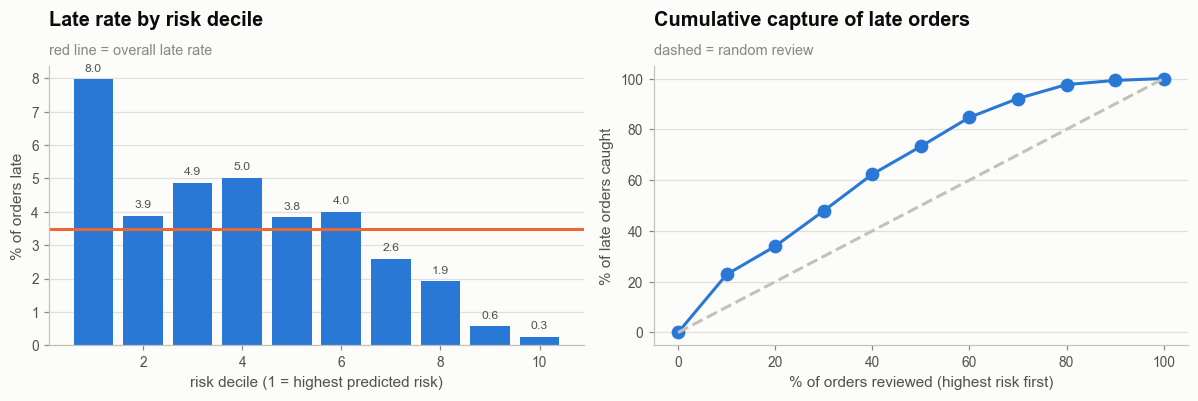

In [30]:
gain = P.gain_table(te_b.clf_target, score_b)
display(gain); PL.gain_chart(gain); plt.show()

**Final model by month of the stress-test window**

In [31]:
by_month = P.test_by_month(fit_b[FINAL_B], te_b, fs_b)
by_month

,Month,Orders,Late rate,PR-AUC,Lift,ROC-AUC
0,2018-05,692.000,0.003,0.031,10.716,0.933
1,2018-06,"6,096.000",0.012,0.074,6.356,0.778
2,2018-07,"6,156.000",0.034,0.082,2.419,0.628
3,2018-08,"6,351.000",0.062,0.073,1.176,0.526


**Four consecutive test windows: lift by model** (1 = no skill)

In [32]:
roll = P.rolling_windows(clf_models, orders, fs_b)
roll.pivot(index="Window", columns="Model", values="Lift")[P.ORDER_B].rename(columns=lambda c: c.split(": ")[-1])

Model,Prior predictor (dummy),LogisticRegression (plain),Logistic (L2),DecisionTree (baseline),RandomForest,Voting (Logit + RF)
Window,,,,,,
W1,1.000,1.465,1.473,1.138,1.445,1.479
W2,1.000,1.710,1.812,1.238,1.575,1.683
W3,1.000,2.245,2.264,1.357,2.109,2.238
W4,1.000,1.998,1.979,1.615,1.179,1.762


**Final model in each window, including the link to 1–2 star reviews**

In [33]:
roll[roll.Model == FINAL_B].drop(columns="Model").set_index("Window")

,Test dates,Train orders,Test orders,Late rate,Median promise (days),PR-AUC,Lift,ROC-AUC,Recall@10%,Precision@10%,"Low-review rate, flagged","Low-review rate, not flagged",Share of low reviews flagged
Window,,,,,,,,,,,,,
W1,01 Sep 2017 to 30 Nov 2017,18237,15916,0.080,22.276,0.117,1.465,0.620,0.178,0.143,0.185,0.128,0.138
W2,01 Dec 2017 to 01 Mar 2018,30897,19139,0.091,25.562,0.156,1.710,0.655,0.202,0.183,0.208,0.153,0.131
W3,01 Mar 2018 to 26 May 2018,50268,19857,0.104,21.967,0.235,2.245,0.719,0.289,0.302,0.271,0.135,0.182
W4,26 May 2018 to 29 Aug 2018,70241,19295,0.035,20.342,0.070,1.998,0.672,0.228,0.080,0.110,0.095,0.114


**Lateness and 1–2 star reviews** (descriptive)

In [34]:
sat = P.satisfaction_link(orders)
sat

,metric,value
0,orders with a review,"95,830.000"
1,"low-review rate (1-2 stars), all",0.128
2,"low-review rate, late orders",0.624
3,"low-review rate, on-time orders",0.093
4,share of low reviews from late orders,0.324


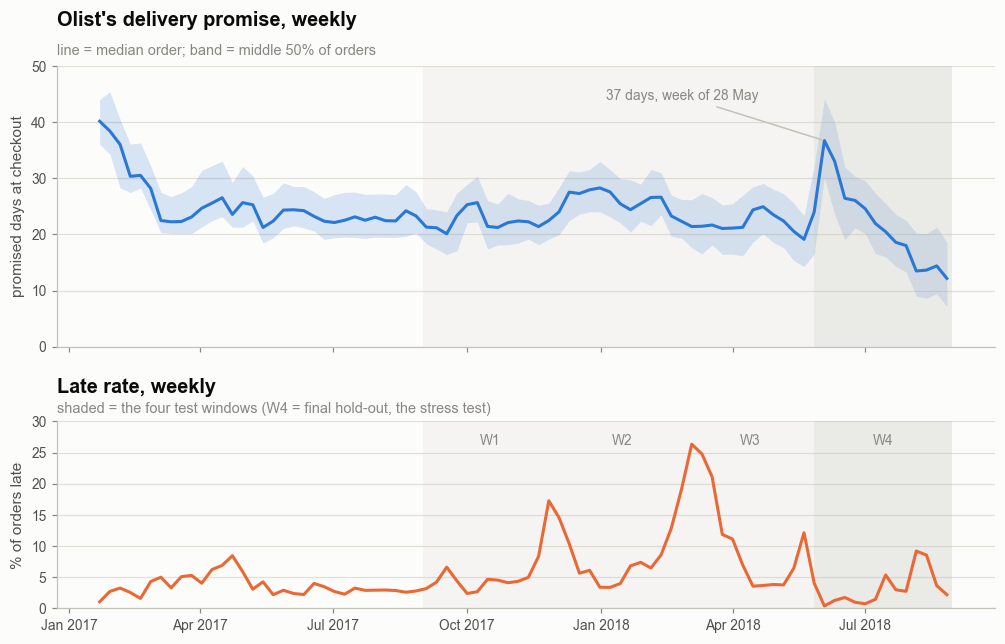

In [35]:
wk = P.promise_timeline(orders)
PL.promise_chart(wk, P.window_starts(orders), orders.order_purchase_timestamp.max()); plt.show()

**Results across windows.** Every model beats chance in every window, and skill rises from W1 to W3 as more history accumulates: plain logistic regression's lift is 1.47, 1.71, 2.24 and 2.00, the forest's 1.45, 1.57, 2.11 and 1.18. Logistic models lead in all four windows; L2 logistic edges plain logistic by at most 0.10 (W2), and plain logistic is best in the stress test, where the forest falls back. W2 and W3 contain the late spikes (9.1% and 10.4% late) and the model keeps its ranking skill; W4 has the lowest late rate (3.5%) and the largest swings in the promise (top panel of the chart). Flagging the riskiest 10% of orders catches 18–29% of late orders.

**Satisfaction.** Late orders receive a 1–2 star review 62% of the time against 9% for on-time orders, but only 32% of all low reviews come from late orders. Accordingly, orders the model flags go on to receive low reviews 1.2–2.0 times as often as unflagged ones (for example 27.1% vs 13.5% in W3), and the flagged 10% of orders hold 11–18% of all low reviews, against 10% for random review: a real but modest payoff.

## 11. Problem 1: robustness, a transparent tariff and the unusual-freight audit

**Robustness.** 78% of test items are products that also appear in training, and a forest can partly memorise a listing's own past freight. We therefore re-test the tuned models on a hold-out **grouped by `product_id`** (every test item is a listing never seen in training) and on a **time-ordered** hold-out (latest 20% of items).

**Transparent tariff.** Phase 1 argued for keeping a model whose coefficients read as an implied tariff. A plain least-squares fit of freight on chargeable weight, distance and a same-state flag gives exactly that, in R\$.

**Audit.** Phase 1 warned that a flexible model can absorb a seller's habitual overcharging into its fit. The audit therefore uses the **product-grouped** models: residuals are computed only on listings the models never saw. Items in the top 5% of positive log-residuals are flagged; with no ground-truth overcharge label we report *stability across two specifications* (RandomForest vs Ridge) and export the 30 cases flagged most strongly by both, with their context, for manual review (precision-at-k, as proposed in Phase 1). Identical units of one listing in one order count as one case.

**Problem 1 — same tuned models on three hold-outs**

In [36]:
names_a = ["Mean predictor (dummy)", "Linear: Ridge", "Tree: RandomForest"]
rob_a, (ptr, pte, pfit) = P.robustness_regression({n: reg_models[n] for n in names_a}, items, fs_a, test_a)
rob_a

,Split,Model,MAE_rs,RMSE_rs,R2_rs
0,Order-grouped (main),Mean predictor (dummy),7.742,16.197,-0.033
1,Order-grouped (main),Linear: Ridge,4.738,11.070,0.517
2,Order-grouped (main),Tree: RandomForest,3.552,8.452,0.719
3,Product-grouped (unseen listings),Mean predictor (dummy),7.815,15.923,-0.033
4,Product-grouped (unseen listings),Linear: Ridge,4.875,11.010,0.506
5,Product-grouped (unseen listings),Tree: RandomForest,4.037,8.983,0.671
6,Time-ordered (latest 20%),Mean predictor (dummy),9.614,19.478,-0.072
7,Time-ordered (latest 20%),Linear: Ridge,6.124,14.245,0.427
8,Time-ordered (latest 20%),Tree: RandomForest,5.459,12.086,0.587


**Implied tariff** (plain least squares, R\$)

In [37]:
tariff = P.implied_tariff(tr_a, te_a)
tariff

,Term,Value
0,Base charge (R$),9.897
1,Per chargeable kg (R$),1.968
2,Per 100 km (R$),0.860
3,Same-state shipment (R$),-4.416
4,Test MAE of this tariff (R$),5.638


**Unusual-freight audit** on never-seen listings (product-grouped models; top 5% of residuals flagged)

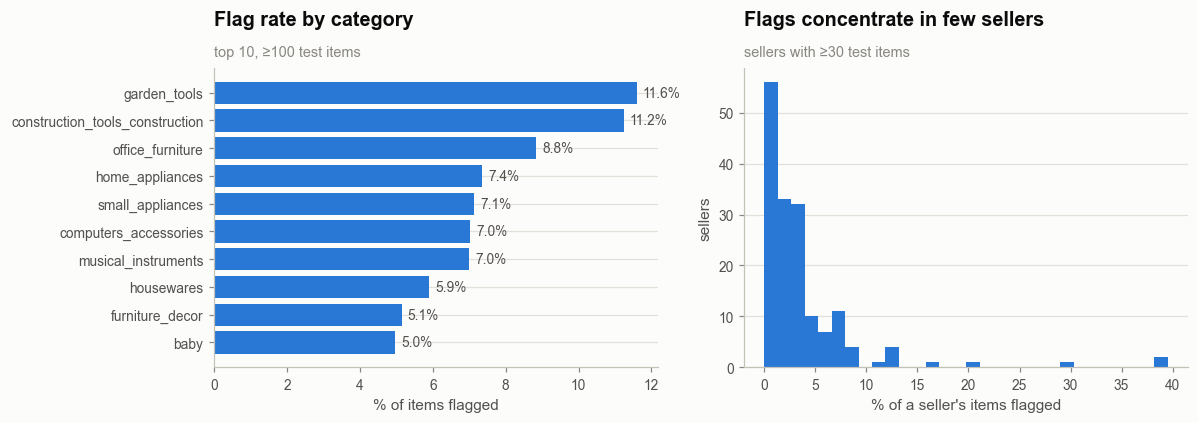

,metric,value
0,items flagged,"1,127.000"
1,mean actual freight R$,53.053
2,mean expected freight R$,26.517
3,mean excess R$,26.535
4,excess as % of all test freight,6.665
5,flagged items from top 5% of sellers (by flag count),57.232
6,flagged by both forest and Ridge (%),69.388
7,agreement of forest and Ridge flags (Jaccard),0.531


In [38]:
flagged, stab = P.flag_overcharge(pte, pfit["Tree: RandomForest"].predict(pte[cols_a]),
                                  pfit["Linear: Ridge"].predict(pte[cols_a]), q=0.95)
sell = PL.overcharge_charts(flagged); plt.show()
audit = P.audit_summary(flagged, stab)
audit

**Sellers with the highest flag rates** (≥30 test items)

In [39]:
top_sellers = sell.sort_values("rate", ascending=False).head(10).reset_index()
top_sellers

,seller_id,n,rate,excess
0,f80edd2c5aaa505cc4b0a3b219abf4b8,43,0.395,437.647
1,25c5c91f63607446a97b143d2d535d31,124,0.395,"1,260.732"
2,00ee68308b45bc5e2660cd833c3f81cc,67,0.299,377.996
3,ad781527c93d00d89a11eecd9dcad7c1,39,0.205,501.552
4,a1043bafd471dff536d0c462352beb48,276,0.163,"2,707.561"
5,1f50f920176fa81dab994f9023523100,373,0.131,"1,057.867"
6,d1c281d3ae149232351cd8c8cc885f0d,62,0.129,279.791
7,0dd184061fb0eaa7ca37932c68ab91c5,39,0.128,71.111
8,640e21a7d01df7614a3b4923e990d40c,58,0.121,157.526
9,17a053fcb14bd219540cbde0df490be0,34,0.118,223.001


**Manual review sheet: top 30 cases (one per order and product) flagged by both models**

In [40]:
review = P.audit_review_sheet(flagged)
review

,order_id,product_id,units,seller_id,category,price,freight_value,expected_rs,excess_rs,weight_kg,volume_cm3,chargeable_kg,distance_km,seller_state,customer_state,reviewer_verdict
0,9d817e85739426de1efcd842ee59cbd1,21d2fdced5c69bfc6539b67908a4ad28,1,1554a68530182680ad5c8b042c3ab563,furniture_living_room,177.990,207.780,31.887,175.893,6.450,"37,950.000",7.590,327.518,MG,RJ,
1,265b23c0727e5d7a2a3e36f5aac03d67,e26445edc4d665a7950a4b60461fc58d,1,527801b552d0077ffd170872eb49683b,books_general_interest,84.900,171.320,26.628,144.692,1.000,"9,856.000",1.971,"2,290.647",SP,CE,
2,fb9e94685fede37314f883d0bb0c2561,6391ff716e6d0271c58f47a692998cf7,1,902c99f1ac505c0d18778b61bcd636f7,housewares,24.490,64.800,10.364,54.436,0.550,"8,000.000",1.600,145.014,SP,SP,
3,5c0623ce8050c2cddeec3575bfbe0a53,4c8fae70c244a7ff63b9c1f73fb0a987,1,0b35c634521043bf4b47e21547b99ab5,construction_tools_construction,109.900,87.830,15.485,72.345,2.750,"4,232.000",2.750,"1,261.043",PR,ES,
4,faca7576168f770d89c21539ff07c9de,b91982b3afff5d274cf34ce54801a8e6,1,485452467ff670447e84a8370c3fc898,unknown,22.900,98.020,17.607,80.413,1.500,"48,000.000",9.600,351.003,SC,RS,
5,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,1,ee27a8f15b1dded4d213a468ba4eb391,art,"6,499.000",227.660,42.767,184.893,7.400,"29,375.000",7.400,616.733,GO,SP,
6,cd51709c98c738351915f79c4318675e,3ebbc0870d51b62783c45e0e61ccb78d,3,7d456afc660226829370f3173d14520c,bed_bath_table,52.000,38.540,7.306,31.234,0.400,"2,592.000",0.518,5.345,SP,SP,
7,e520f0510b121c81ee4602e3851642af,53ea9da485f6aed8a6f03a85831fe021,1,7d13fca15225358621be4086e1eb0964,watches_gifts,277.990,68.820,13.808,55.012,0.346,"2,340.000",0.468,310.516,SP,SP,
8,e82a0445876919a068e9a6101a00b14f,101a896b1137f70a7bbb2b9fac61458d,1,7d13fca15225358621be4086e1eb0964,watches_gifts,285.990,68.870,14.078,54.792,0.342,"1,836.000",0.367,341.389,SP,SP,
9,9561a9943b36636b3756df14b0aa72fc,1d2d3b19f5c3d093d4dbccd3cd963a8f,1,7ddcbb64b5bc1ef36ca8c151f6ec77df,sports_leisure,199.990,58.900,12.924,45.976,2.050,"12,320.000",2.464,9.914,SP,SP,


## 12. Actionable insights
**Problem 2: operations and customer-experience team.**

1. **Use the model as a ranking, not a forecast.** Checking the riskiest 10% of orders reaches 22.8% of late orders in the stress test, more than twice what random checking would reach; the top 30% of orders by risk holds 48% of late orders and the top half 73%. Across the four test windows the same 10% catches 18–29% of late orders (W1–W4: 17.8%, 20.2%, 28.9%, 22.8%). Because precision is low (about 1 late order per 13 checked in the stress test), the intervention must be cheap: a proactive tracking message or a re-set promise, not expedited shipping for every flag.
2. **Late-risk flags carry a modest satisfaction payoff.** Late orders get a 1–2 star review 62% of the time against 9% for on-time orders. Flagged orders go on to receive low reviews 1.2–2.0 times as often as unflagged ones, and the flagged 10% hold 11–18% of all low reviews. Because about two-thirds (68%) of low reviews come from orders that arrived on time, preventing late deliveries addresses only part of dissatisfaction; the rest presumably reflects product and seller quality.
3. **The promise is the lever, so treat estimator changes as events.** Promised days is by far the strongest signal (permutation importance 0.041 PR-AUC; L2 logistic coefficient −0.72 per standard deviation): longer promises make lateness much less likely. In August 2018 Olist cut the median promise from its usual 21–27 days to about 13 days; the late rate rose from 1.2% in June to 6.2% in August and the model's skill fell from lift 6.4 to 1.2. *Action:* when the promise rules change, re-train on the new regime and monitor late rate by promise length before trusting the ranking. The stress test shows why: half of its late orders were São Paulo orders promised under 14 days, a group that was relatively safe in training, and the model flagged only 3% of them (Section 8.2).
4. **Pad promises on high-risk lanes, and re-check them.** Holding the promise fixed, deliveries to Alagoas, Pará, Rio de Janeiro and Maranhão, and from São Paulo and Maranhão sellers, carried higher late odds in the training period; deliveries to Paraná, Minas Gerais, the Federal District and São Paulo carried lower ones. These are training-period estimates: in mid-2018 São Paulo's relative risk rose (Section 8.2), so the lane list must be refreshed with each re-training.
5. **Do not plan around one Black Friday.** Calendar month, purchase timing and platform congestion added nothing, or hurt, when predicting later orders.

**Problem 1: logistics-pricing / finance analyst.**

6. **A fair-freight benchmark is feasible.** The forest predicts freight to within R\$3.55 on average (R² 0.72), and R\$4.04 for listings it has never seen, driven by distance, weight and whether seller and buyer share a state. *Action:* use it as a checkout sanity check. For a published tariff, the transparent least-squares version reads: **R\$9.90 base + R\$1.97 per chargeable kg + R\$0.86 per 100 km − R\$4.42 within a state** (MAE R\$5.64, the price of full transparency).
7. **Unusual freight is concentrated, so audit sellers.** On never-seen listings, 1,127 items (the top 5% of residuals) were charged R\$53.1 against R\$26.5 expected, a mean excess of R\$26.5 and 6.7% of all freight in that test set; the top 5% of sellers account for 57% of the flags, and the forest and Ridge agree on 69% of them. *Action:* review items flagged by both models first; the 30 strongest cases are listed in the review sheet at the end of Section 11 for manual checking.
8. **Be cautious on expensive items.** Test MAE rises from R\$1.9 for items under R\$25 to R\$11.6 above R\$500 (13.7% to 24.4% of mean freight), so use wider tolerance bands before flagging high-ticket items.

## 13. Limitations and constraints
* **Problem 2 skill is modest and decays.** Lift is about 2 on later orders, and within the three-month test window it falls to 1.2 by August 2018 after the change in promise rules. The model needs monthly re-training with forward validation and monitoring of lift by month. Carrier performance, weather and strikes are not in the data, so a ceiling on predictability is expected.
* **Test windows.** There are four, but W1–W3 lie inside the period used to choose the model specification, so only W4 is untouched, and W4 is unusual (late rate 3.5% against 7.7% in training, and two promise changes). No confidence intervals are reported on test metrics.
* **Probabilities are not calibrated.** Because the late rate shifts between periods, predicted probabilities are too high on the test window (Brier 0.041 against 0.035 for the no-skill prior, a constant at the training late rate). The scores are used only as rankings; recalibrating on the latest month would be needed before quoting probabilities.
* **Label and population.** `is_late` means delivered on a calendar day after the promised date and exists only for delivered orders, so the 3% never delivered are out of scope. Order-level aggregation (maximum distance, the seller state of the highest-priced item) discards multi-seller detail.
* **Problem 1 inputs.** Distance is straight-line between zip-prefix centroids, not route distance; how Olist allocates an order's freight across items is undocumented; seller-funded shipping, promotions and carrier tariffs are not in the data. Back-transforming log predictions gives median-like expected freight, so mean excess is slightly overstated. There is no ground-truth overcharge label: flags are leads for review, and the manual review of the top 30 is still to be done.
* **Search and evaluation budget.** The Problem 1 forest was tuned with 8 random draws on a 30,000-row sub-sample; the Problem 2 forest with 20 draws. Permutation importance splits credit between correlated features.

## 14. Reproducibility and AI use
Seed `42` for splits, CV, forests, subsampling and target-encoder cross-fitting. Environment: `requirements.txt` (results produced with the versions printed in the first code cell).

*AI use:* Anthropic Claude (via Claude Code) was used to help write and refactor the analysis code, run experiments and draft text. The team reviewed and takes responsibility for all code, results and interpretation.